# GAT Session Recommendation Results Analysis

This notebook summarizes the completed `GAT-SR-GNN` and `GAT-TAGNN` runs in `results/` and compares them with the SR-GNN and TAGNN paper values.

In [35]:
from pathlib import Path
import os
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd()
RESULTS_DIR = PROJECT_ROOT / "results"
CHECKPOINTS_DIR = RESULTS_DIR / "checkpoints"
RESULTS_DIR.mkdir(exist_ok=True)

plt.style.use("seaborn-v0_8-whitegrid")
pd.options.display.float_format = "{:.3f}".format


def bold_numeric_column_max(table, precision=3):
    """Return a Styler that bolds the maximum value in each numeric column."""
    numeric_columns = table.select_dtypes(include="number").columns

    def highlight(column):
        if column.name not in numeric_columns or column.empty:
            return [""] * len(column)
        max_value = column.max(skipna=True)
        return ["font-weight: bold" if value == max_value else "" for value in column]

    return table.style.apply(highlight, axis=0).format(precision=precision)


In [36]:
# Literature values from the TAGNN paper table supplied in the prompt.
# Columns are ordered with Yoochoose first, then Diginetica, to match the current analysis focus.
tagnn_baselines = pd.DataFrame([
    ["POP", 6.71, 1.65, 0.89, 0.20],
    ["S-POP", 30.44, 18.35, 21.06, 13.68],
    ["Item-KNN", 51.60, 21.81, 35.75, 11.57],
    ["BPR-MF", 31.31, 12.08, 5.24, 1.98],
    ["FPMC", 45.62, 15.01, 26.53, 6.95],
    ["GRU4REC", 60.64, 22.89, 29.45, 8.33],
    ["NARM", 68.32, 28.63, 49.70, 16.17],
    ["STAMP", 68.74, 29.67, 45.64, 14.32],
    ["SR-GNN", 70.57, 30.94, 50.73, 17.59],
    ["TAGNN", 71.02, 31.12, 51.31, 18.03],
], columns=["method", "yoochoose_1_64_precision@20", "yoochoose_1_64_mrr@20", "diginetica_precision@20", "diginetica_mrr@20"])

sr_reference = {
    ("Yoochoose 1/64", "Precision@20"): 70.57,
    ("Yoochoose 1/64", "MRR@20"): 30.94,
    ("Diginetica", "Precision@20"): 50.73,
    ("Diginetica", "MRR@20"): 17.59,
}
tag_reference = {
    ("Yoochoose 1/64", "Precision@20"): 71.02,
    ("Yoochoose 1/64", "MRR@20"): 31.12,
    ("Diginetica", "Precision@20"): 51.31,
    ("Diginetica", "MRR@20"): 18.03,
}

# The main paper-style table is displayed later with the GAT rows appended.

In [37]:
sr_results = pd.read_csv(RESULTS_DIR / "gat_sr_gnn_results.csv").assign(model="GAT-SR-GNN")
tag_results = pd.read_csv(RESULTS_DIR / "gat_tagnn_results.csv").assign(model="GAT-TAGNN")
model_summary = pd.concat([sr_results, tag_results], ignore_index=True)
model_summary = model_summary[[
    "model", "dataset", "test_precision@20", "test_mrr@20", "test_loss", "best_epoch",
    "best_validation_precision@20", "best_validation_mrr@20", "train_examples",
    "validation_examples", "test_examples", "num_items", "checkpoint_path",
]]
model_summary.to_csv(RESULTS_DIR / "model_summary.csv", index=False)

# Readable paper-style table: original TAGNN comparison table plus the two completed GAT runs.
gat_rows = []
for model_name in ["GAT-SR-GNN", "GAT-TAGNN"]:
    model_rows = model_summary[model_summary["model"] == model_name].set_index("dataset")
    gat_rows.append({
        "method": model_name,
        "yoochoose_1_64_precision@20": model_rows.loc["Yoochoose 1/64", "test_precision@20"],
        "yoochoose_1_64_mrr@20": model_rows.loc["Yoochoose 1/64", "test_mrr@20"],
        "diginetica_precision@20": model_rows.loc["Diginetica", "test_precision@20"],
        "diginetica_mrr@20": model_rows.loc["Diginetica", "test_mrr@20"],
    })
paper_comparison_with_gat = pd.concat([tagnn_baselines, pd.DataFrame(gat_rows)], ignore_index=True)
paper_comparison_with_gat = paper_comparison_with_gat[[
    "method",
    "yoochoose_1_64_precision@20",
    "yoochoose_1_64_mrr@20",
    "diginetica_precision@20",
    "diginetica_mrr@20",
]]
paper_comparison_with_gat.to_csv(RESULTS_DIR / "paper_comparison_with_gat.csv", index=False)

plot_comparison = paper_comparison_with_gat[
    paper_comparison_with_gat["method"].isin(["SR-GNN", "TAGNN", "GAT-SR-GNN", "GAT-TAGNN"])
].copy()

# Compact machine-readable deltas for plots and saved CSVs. These are intentionally not displayed.
comparison_rows = []
for row in model_summary.to_dict("records"):
    if row["model"] == "GAT-SR-GNN":
        reference_method = "SR-GNN"
        reference = sr_reference
    else:
        reference_method = "TAGNN"
        reference = tag_reference
    for metric, column in [("Precision@20", "test_precision@20"), ("MRR@20", "test_mrr@20")]:
        value = row[column]
        reference_value = reference[(row["dataset"], metric)]
        comparison_rows.append({
            "model": row["model"],
            "reference_method": reference_method,
            "dataset": row["dataset"],
            "metric": metric,
            "model_value": value,
            "reference_value": reference_value,
            "delta": value - reference_value,
            "relative_delta_%": 100.0 * (value - reference_value) / reference_value,
        })
literature_comparison = pd.DataFrame(comparison_rows)
literature_comparison.to_csv(RESULTS_DIR / "literature_comparison.csv", index=False)

head_to_head = model_summary.pivot(index="dataset", columns="model", values=["test_precision@20", "test_mrr@20"])
head_to_head = pd.DataFrame({
    "dataset": head_to_head.index,
    "gat_sr_gnn_precision@20": head_to_head[("test_precision@20", "GAT-SR-GNN")].values,
    "gat_tagnn_precision@20": head_to_head[("test_precision@20", "GAT-TAGNN")].values,
    "precision_delta_tagnn_minus_sr": head_to_head[("test_precision@20", "GAT-TAGNN")].values - head_to_head[("test_precision@20", "GAT-SR-GNN")].values,
    "gat_sr_gnn_mrr@20": head_to_head[("test_mrr@20", "GAT-SR-GNN")].values,
    "gat_tagnn_mrr@20": head_to_head[("test_mrr@20", "GAT-TAGNN")].values,
    "mrr_delta_tagnn_minus_sr": head_to_head[("test_mrr@20", "GAT-TAGNN")].values - head_to_head[("test_mrr@20", "GAT-SR-GNN")].values,
})
head_to_head.to_csv(RESULTS_DIR / "gat_head_to_head.csv", index=False)

display(bold_numeric_column_max(paper_comparison_with_gat))

,method,yoochoose_1_64_precision@20,yoochoose_1_64_mrr@20,diginetica_precision@20,diginetica_mrr@20
0,POP,6.710,1.650,0.890,0.200
1,S-POP,30.440,18.350,21.060,13.680
2,Item-KNN,51.600,21.810,35.750,11.570
3,BPR-MF,31.310,12.080,5.240,1.980
4,FPMC,45.620,15.010,26.530,6.950
5,GRU4REC,60.640,22.890,29.450,8.330
6,NARM,68.320,28.630,49.700,16.170
7,STAMP,68.740,29.670,45.640,14.320
8,SR-GNN,70.570,30.940,50.730,17.590
9,TAGNN,71.020,31.120,51.310,18.030


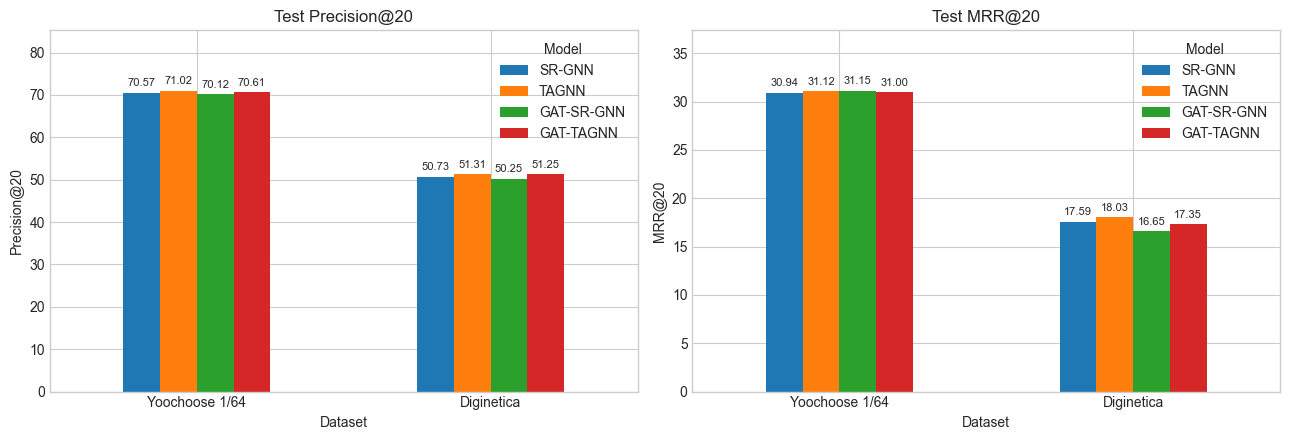

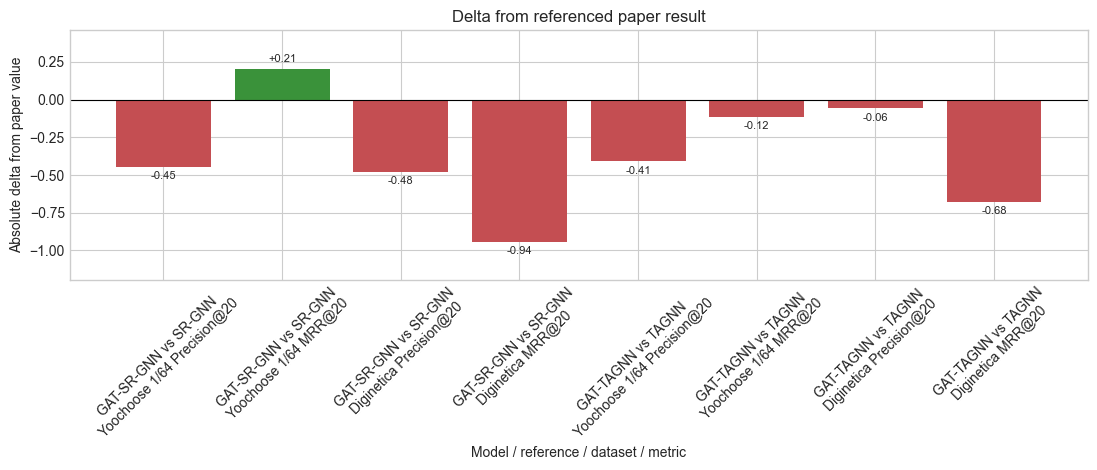

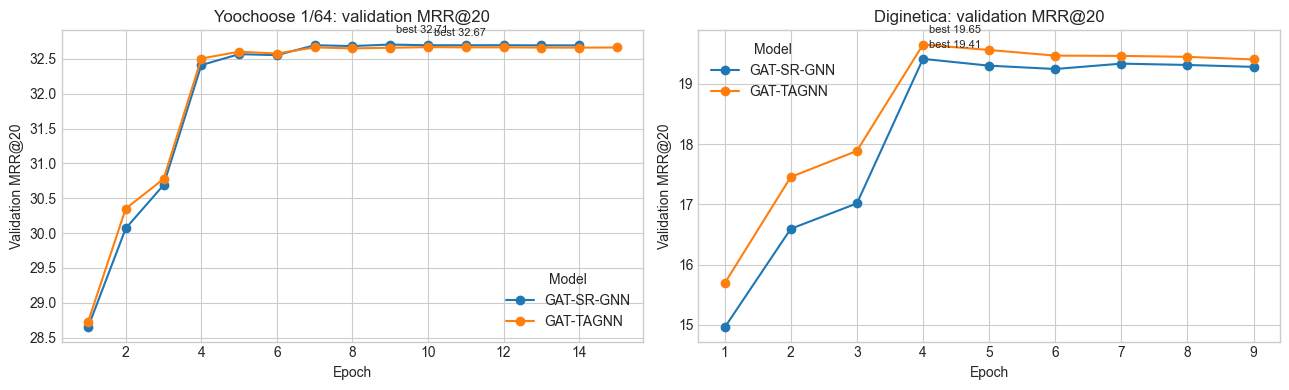

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
plot_methods = ["SR-GNN", "TAGNN", "GAT-SR-GNN", "GAT-TAGNN"]
metric_specs = [
    (
        "Test Precision@20",
        ["yoochoose_1_64_precision@20", "diginetica_precision@20"],
        ["Yoochoose 1/64", "Diginetica"],
    ),
    (
        "Test MRR@20",
        ["yoochoose_1_64_mrr@20", "diginetica_mrr@20"],
        ["Yoochoose 1/64", "Diginetica"],
    ),
]
for ax, (title, columns, dataset_labels) in zip(axes, metric_specs):
    plot_data = plot_comparison.set_index("method").loc[plot_methods, columns].T
    plot_data.index = dataset_labels
    plot_data.plot(kind="bar", ax=ax, rot=0)
    ax.set_title(title)
    ax.set_xlabel("Dataset")
    ax.set_ylabel(title.replace("Test ", ""))
    ax.legend(title="Model")
    for container in ax.containers:
        ax.bar_label(container, fmt="%.2f", padding=3, fontsize=8)
    ax.margins(y=0.2)
fig.tight_layout()
fig.savefig(RESULTS_DIR / "model_summary.png", dpi=180, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(11, 4.8))
delta_plot = literature_comparison.assign(
    label=lambda df: df["model"] + " vs " + df["reference_method"] + "\n" + df["dataset"] + " " + df["metric"]
)
bars = ax.bar(
    delta_plot["label"],
    delta_plot["delta"],
    color=["#3a923a" if x >= 0 else "#c44e52" for x in delta_plot["delta"]],
)
ax.axhline(0, color="black", linewidth=0.8)
ax.bar_label(bars, fmt="%+.2f", padding=3, fontsize=8)
ax.set_ylabel("Absolute delta from paper value")
ax.set_xlabel("Model / reference / dataset / metric")
ax.set_title("Delta from referenced paper result")
ax.tick_params(axis="x", rotation=45)
ax.margins(y=0.22)
fig.tight_layout()
fig.savefig(RESULTS_DIR / "literature_delta.png", dpi=180, bbox_inches="tight")
plt.show()

histories = []
for model, filename in [("GAT-SR-GNN", "gat_sr_gnn_history.csv"), ("GAT-TAGNN", "gat_tagnn_history.csv")]:
    histories.append(pd.read_csv(RESULTS_DIR / filename).assign(model=model))
history = pd.concat(histories, ignore_index=True)
fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharex=False)
for dataset, ax in zip(["Yoochoose 1/64", "Diginetica"], axes):
    subset = history[history["dataset"] == dataset]
    for model, group in subset.groupby("model"):
        ax.plot(group["epoch"], group["validation_mrr@20"], marker="o", label=model)
        best_row = group.loc[group["validation_mrr@20"].idxmax()]
        ax.annotate(
            f"best {best_row['validation_mrr@20']:.2f}",
            xy=(best_row["epoch"], best_row["validation_mrr@20"]),
            xytext=(4, 8),
            textcoords="offset points",
            fontsize=8,
        )
    ax.set_title(f"{dataset}: validation MRR@20")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Validation MRR@20")
    ax.legend(title="Model")
fig.tight_layout()
fig.savefig(RESULTS_DIR / "training_curves.png", dpi=180, bbox_inches="tight")
plt.show()

## Current Findings

`GAT-TAGNN` is the stronger of the two completed GAT variants on Precision@20 for both datasets. On Yoochoose 1/64 it reaches 70.61 P@20, which is 0.41 below the original TAGNN table value, and on Diginetica it reaches 51.25 P@20, only 0.06 below TAGNN. Its MRR@20 is slightly below TAGNN on both datasets.

`GAT-SR-GNN` is close to the original SR-GNN P@20 values but does not clearly beat them. The one positive literature delta is Yoochoose 1/64 MRR@20: 31.15 versus original SR-GNN's 30.94.

These comparisons are descriptive rather than a direct proof of GAT superiority because the original paper numbers were produced in their own implementations. A direct GGNN baseline under this repository's exact preprocessing and evaluation is still needed for the central GGNN-vs-GAT claim.